In [1]:
# Neural Network Analysis Demo
# This notebook demonstrates how to use the NetworkAnalyzer and WeightBinning classes

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split

# Add parent directory to Python path to import from sibling directories
import sys
import os
# Get the absolute path of the current notebook's directory
notebook_dir = os.path.dirname(os.path.abspath('__file__'))
# Get the parent directory
parent_dir = os.path.dirname(notebook_dir)
# Add parent directory to path
sys.path.append(parent_dir)

from Architectures.permutation_free_architecture import PermutationFreeNet
from Architectures.standardRegArchitecture import SimpleNet
from Classes.weight_binning import WeightBinning
from Classes.network_analyzer import NetworkAnalyzer


def load_data(batch_size):
    csv_data = pd.read_csv('/home2/coles8/Large-Scale-Design-and-Analysis-of-Neural-Networks/data/simpleReg.csv')
    a = csv_data['a'].values.reshape(-1, 1)
    b = csv_data['b'].values.reshape(-1, 1)
    y = csv_data['y'].values.reshape(-1, 1)

    a_tensor = torch.tensor(a, dtype=torch.float32)
    b_tensor = torch.tensor(b, dtype=torch.float32)
    y_tensor = torch.tensor(y, dtype=torch.float32)
    X_tensor = torch.cat((a_tensor, b_tensor), dim=1)

    X_train, X_test, y_train, y_test = train_test_split(X_tensor, y_tensor, test_size=0.2, random_state=42)
    train_dataset = TensorDataset(X_train, y_train)
    test_dataset = TensorDataset(X_test, y_test)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size)
    return train_loader, test_loader

train_loader, test_loader = load_data(batch_size=64)

In [2]:
save_dir = "/home2/coles8/Large-Scale-Design-and-Analysis-of-Neural-Networks/outputs/packageTest"
all_networks_dir = "/home2/coles8/savedNetworks/"

# analyzer = NetworkAnalyzer(
#     model_architecture=SimpleNet,
#     amount_to_produce=10,
#     success_loss=0.2,
#     convergence_threshold=0.001,
#     max_attempts=10,
#     save_dir=save_dir
# )

# print("Generating networks...")
# analyzer.generate_networks(
#     train_loader=train_loader,
#     test_loader=test_loader,
#     num_epochs=5,
#     loss_fn=nn.MSELoss(),
#     learning_rate=0.05
# )



In [3]:
# Set the architecture, save directory, and load path
architecture = SimpleNet
wb_save_dir = f"{save_dir}/binning" 
# load_path = f"{save_dir}/working_networks.pt"
load_path = f"{all_networks_dir}/simpleNet100k.pt"

# Instantiate WeightBinning
wb = WeightBinning(architecture=architecture, save_dir=wb_save_dir, load_path=load_path)


Number of networks loaded:
100000
Loaded models
Stored weights


Normalizing distributions...
Fitting Gaussian models...
Clustering Gaussians with KL threshold 1e-05...
Plotting unique Gaussian distributions for layer 0...
Plotting unique Gaussian cluster 0 at position (0, 0)


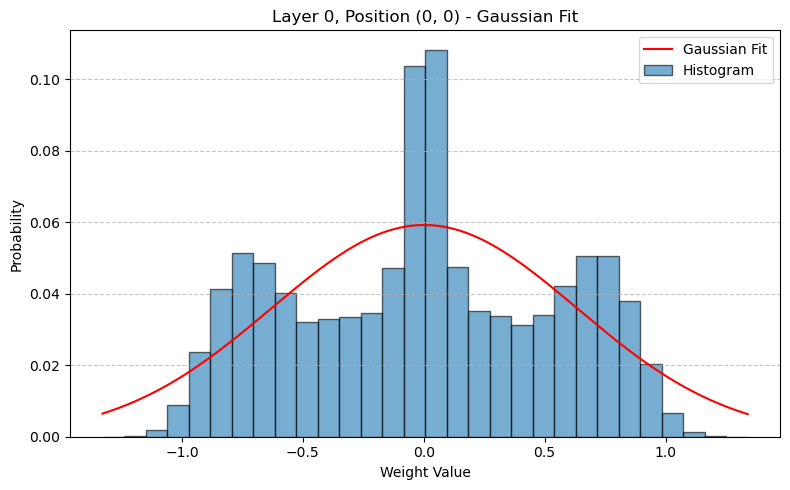

Plotting unique Gaussian cluster 1 at position (0, 1)


<Figure size 640x480 with 0 Axes>

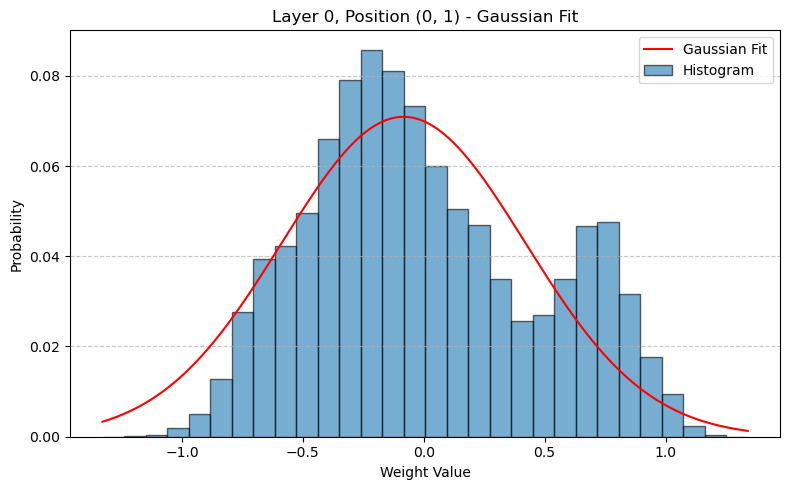

Plotting unique Gaussian cluster 2 at position (1, 0)


<Figure size 640x480 with 0 Axes>

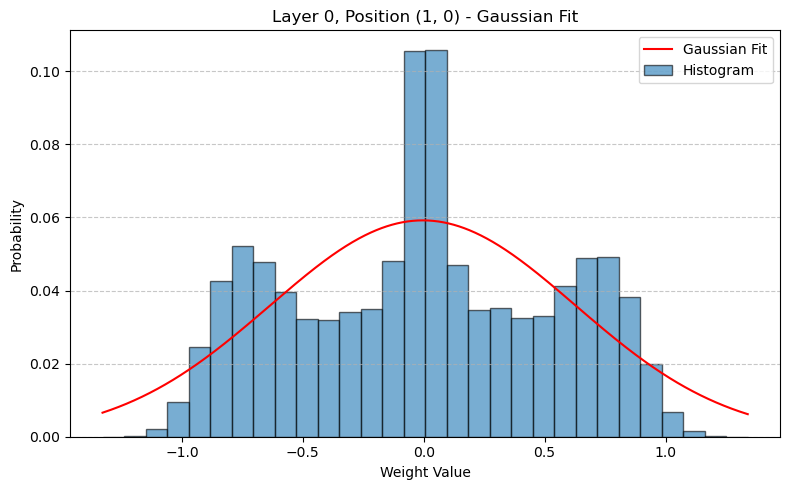

Plotting unique Gaussian cluster 3 at position (1, 1)


<Figure size 640x480 with 0 Axes>

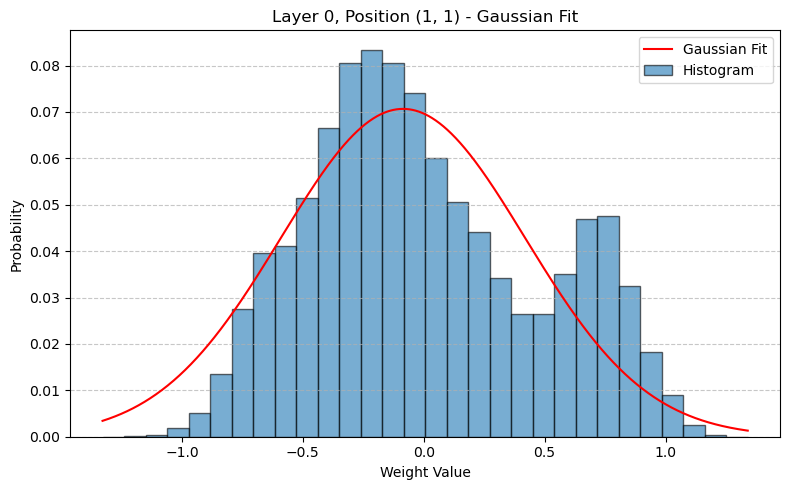

Plotting unique Gaussian cluster 4 at position (2, 1)


<Figure size 640x480 with 0 Axes>

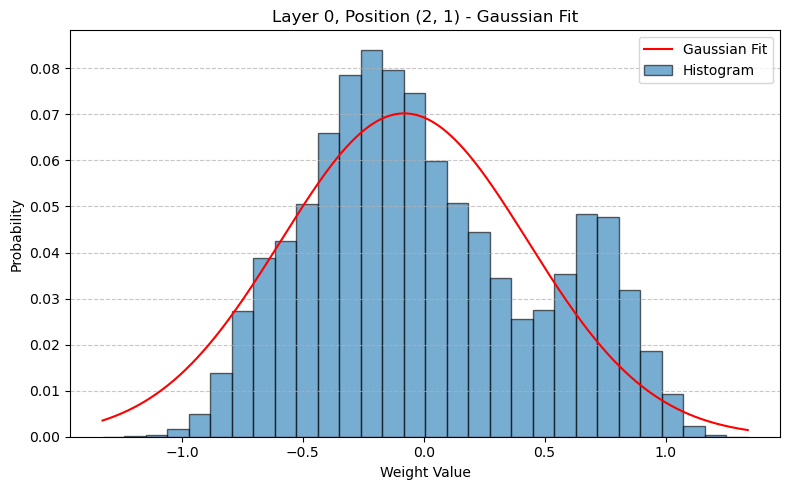

Found 5 unique Gaussian distributions in layer 0


<Figure size 640x480 with 0 Axes>

In [4]:
# Example 1: Analyze with Single-peak Gaussians
cluster_indices = wb.analyze_distributions(
    layer=0,
    kl_threshold=0.00001,
    multi_peak=False
)

Fitting GMM models...
Clustering GMMs with KL threshold 1e-05...
Plotting unique GMM distributions for layer 0...
Plotting unique GMM cluster 0 at position (0, 0)


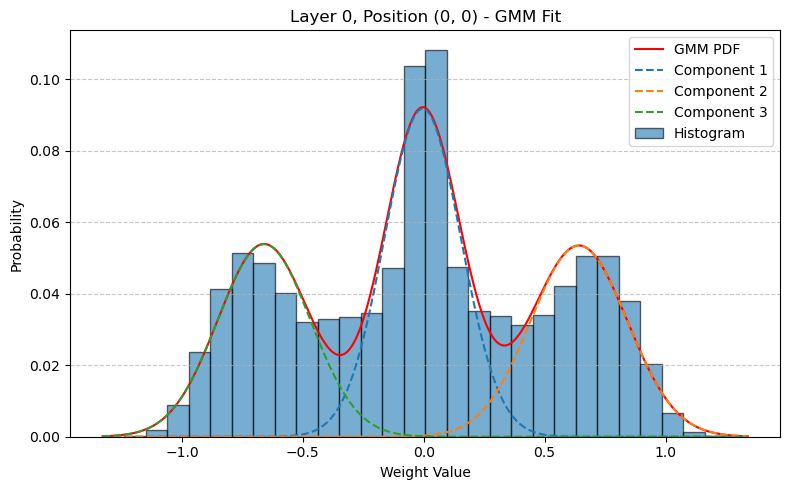

Plotting unique GMM cluster 1 at position (0, 1)


<Figure size 640x480 with 0 Axes>

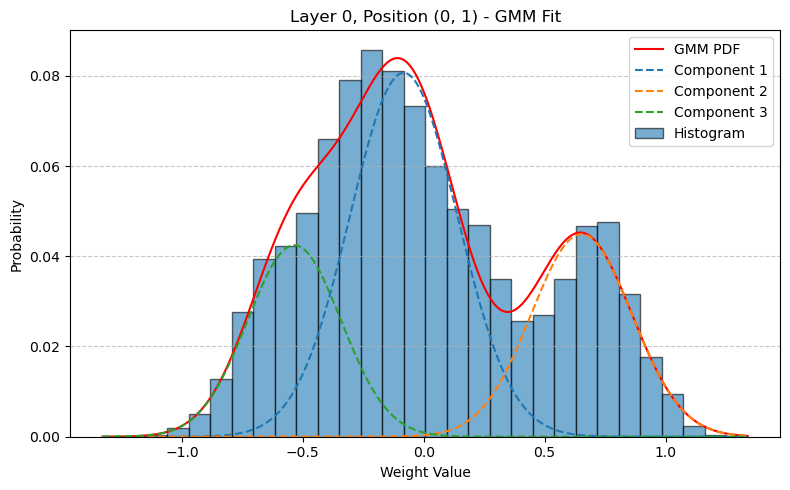

Plotting unique GMM cluster 2 at position (1, 0)


<Figure size 640x480 with 0 Axes>

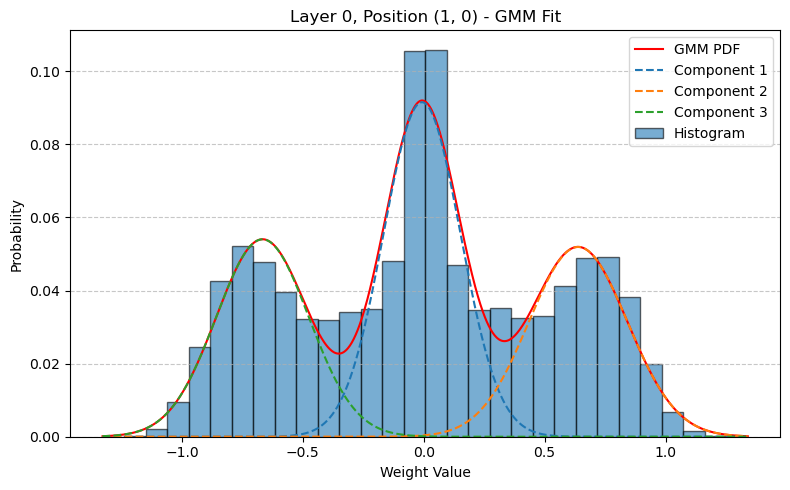

Plotting unique GMM cluster 3 at position (1, 1)


<Figure size 640x480 with 0 Axes>

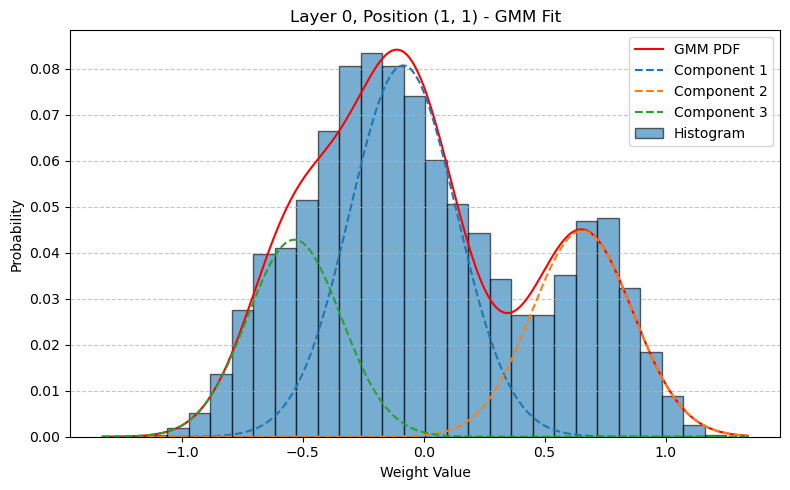

Plotting unique GMM cluster 4 at position (2, 0)


<Figure size 640x480 with 0 Axes>

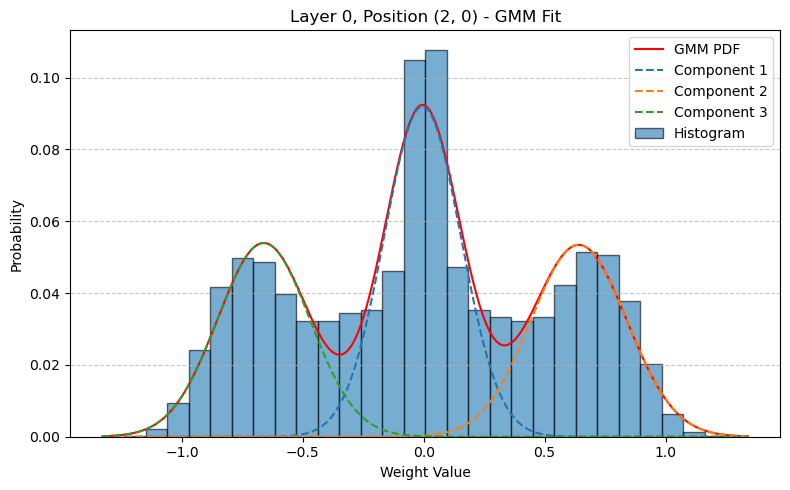

Plotting unique GMM cluster 5 at position (2, 1)


<Figure size 640x480 with 0 Axes>

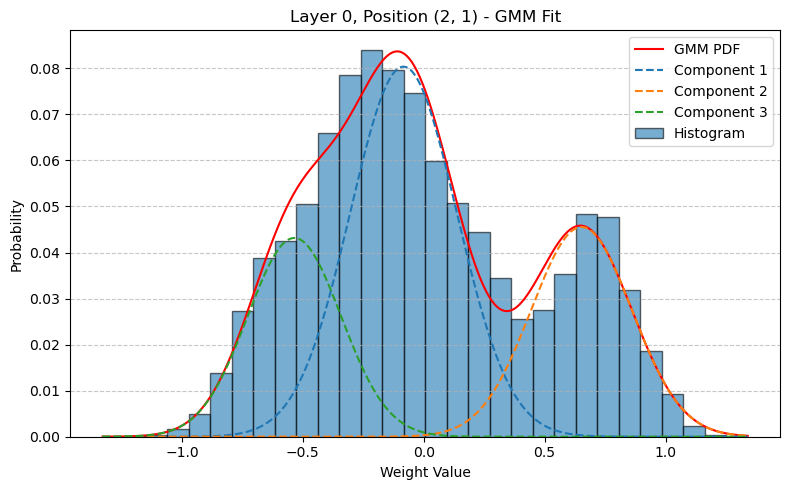

Plotting unique GMM cluster 6 at position (3, 0)


<Figure size 640x480 with 0 Axes>

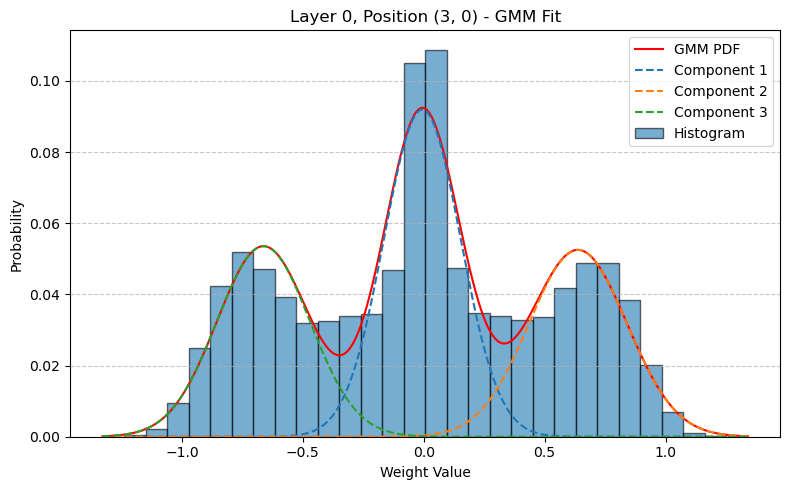

Plotting unique GMM cluster 7 at position (3, 1)


<Figure size 640x480 with 0 Axes>

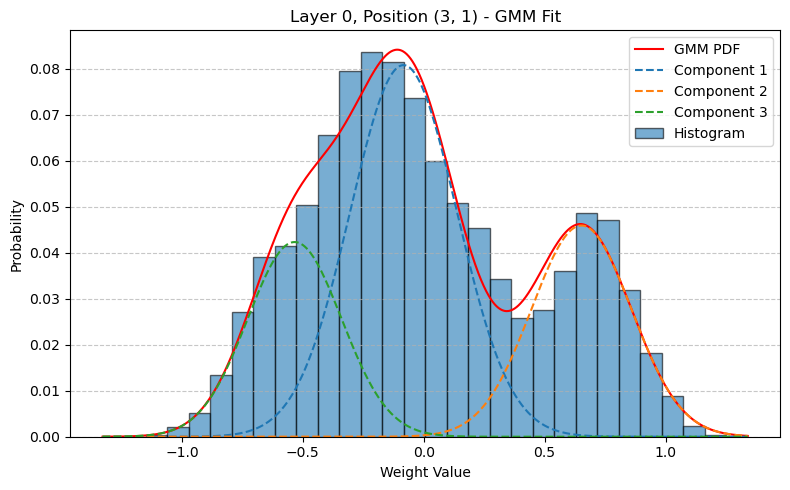

Plotting unique GMM cluster 8 at position (4, 0)


<Figure size 640x480 with 0 Axes>

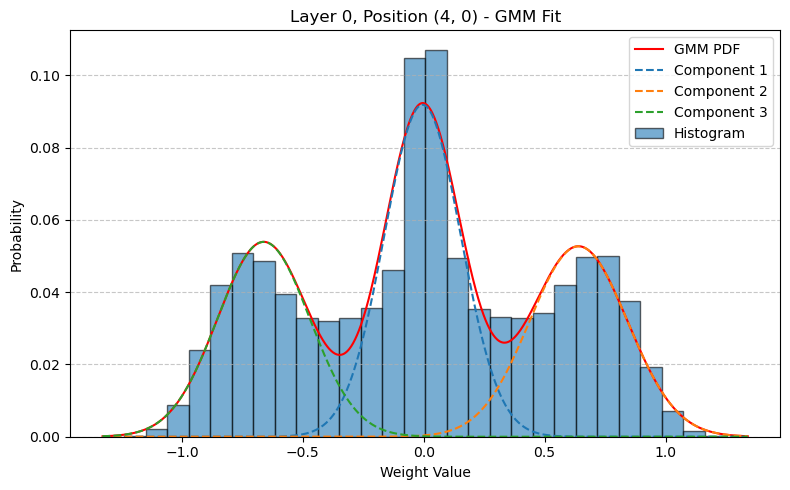

Plotting unique GMM cluster 9 at position (4, 1)


<Figure size 640x480 with 0 Axes>

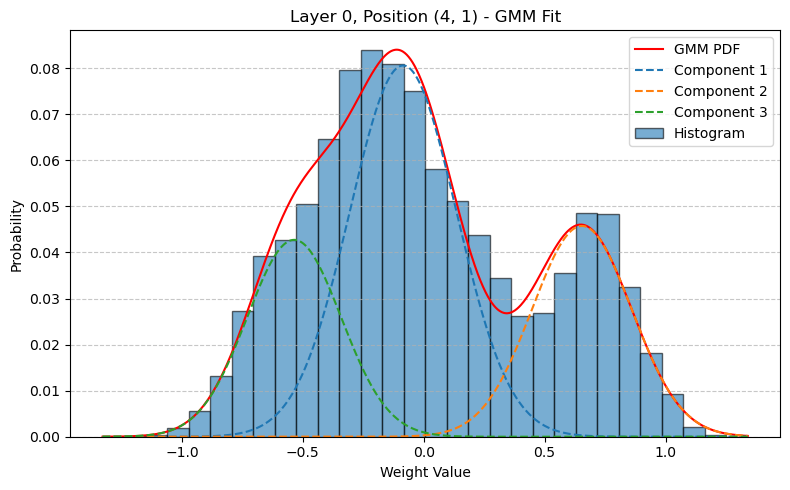

Found 10 unique GMM distributions in layer 0


<Figure size 640x480 with 0 Axes>

In [5]:
# Example 2: Analyze with Multi-peak GMMs
gmm_cluster_indices = wb.analyze_distributions(
    layer=0,
    kl_threshold=0.00001,
    multi_peak=True,
    peaks_per_layer=[3, 1, 2]
)


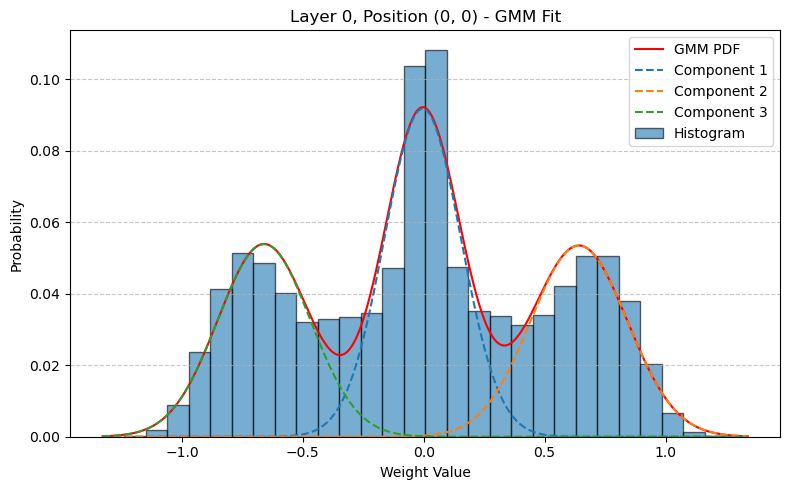

<Figure size 640x480 with 0 Axes>

In [6]:
# Example 3: Look at specific weight position with Multi-peak GMM
wb.fit_distributions(
    multi_peak=True, 
    peaks_per_layer=[3, 1, 2],
    random_state=42
)
wb.plot_distribution(
    layer=0,
    weight_position=(0, 0),
    multi_peak=True,
    scale_to_hist=True,
    show_individual=True
)

Starting interactive weight walkthrough...
Neuron 0, Incoming Weight 0


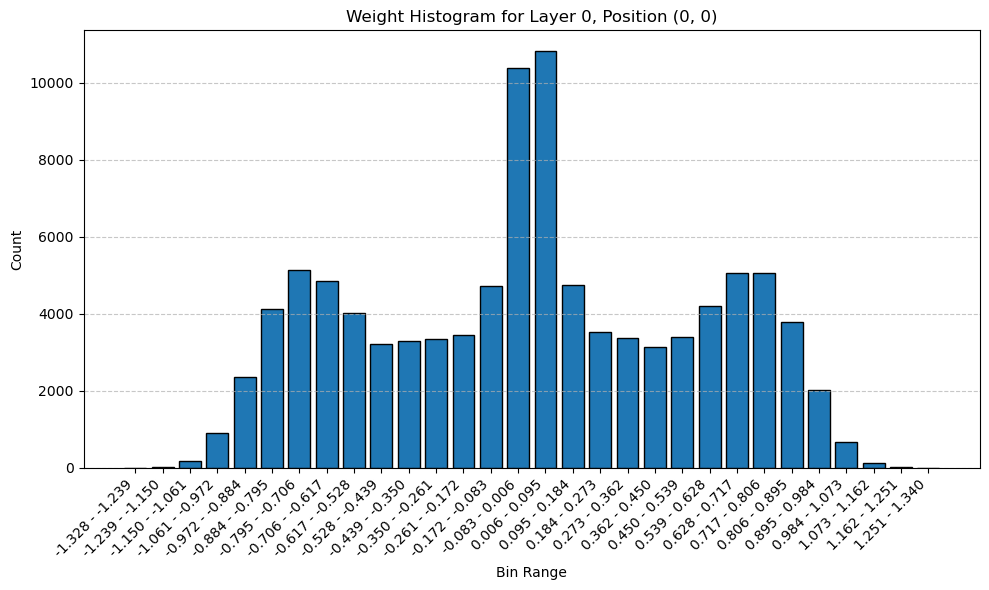

In [ ]:
# Example 4: Analyze with Single-peak Gaussians with walkthrough
cluster_indices = wb.analyze_distributions(
    layer=0,
    kl_threshold=0.00001,
    multi_peak=False,
    run_walkthrough=True
)